In [1]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pickle

from functions import *
import h5py
import numpy as np
from rand_funcs import *
import copy

import h5py
import warnings

def load_obj(name):
    with open('bestfits/' + name + '.pkl', 'rb') as f:
        obj = pickle.load(f)
        print(name+':')
        if 'varied' in name:
            for z in obj.keys():
                print('z = '+z)
                p1, p2, p3, p4, p5, p6 = obj[z]['Transition point'], obj[z]['Pre-disk slope'],\
                                         obj[z]['Pre-disk normalization'], obj[z]['Pre-disk sigma'],\
                                         obj[z]['Post-disk sigma'], obj[z]['Post-disk normalization']
                print(z+' & $10^{'+str(p1)+'}$ & '+str(p2)+' & $10^{'+str(p3)+'}$ & '+str(p4)+' & '+str(p5)+' & '+str(p6)+' \\')
                print('\n')
        else:
            p1, p2, p3, p4, p5, p6 = obj['Transition point'], obj['Pre-disk slope'],\
                                     obj['Pre-disk normalization'], obj['Pre-disk sigma'],\
                                     obj['Post-disk sigma'], obj['Post-disk normalization']
            print('ALL & $10^{'+str(p1)+'}$ & '+str(p2)+' & $10^{'+str(p3)+'}$ & '+str(p4)+' & '+str(p5)+' & '+str(p6)+' \\')
            print('\n')
        return obj

In [2]:
def organize_set_varied_dicts(set_dict, varied_dict):
    fixed_params = {'Mscrit':set_dict['Transition point'], 'presig':set_dict['Pre-disk sigma'],\
                'postsig':set_dict['Post-disk sigma'], 'preslope': set_dict['Pre-disk slope'],\
                'Mbhnorm':set_dict['Pre-disk normalization'], 'postnorm':set_dict['Post-disk normalization']} #allowing no parameters to vary

    varied_params = {'Mscrit':[varied_dict[v]['Transition point'] for v in varied_dict],\
              'presig':[varied_dict[v]['Pre-disk sigma'] for v in varied_dict],\
              'postsig':[varied_dict[v]['Post-disk sigma'] for v in varied_dict],\
              'preslope':[varied_dict[v]['Pre-disk slope'] for v in varied_dict],\
              'Mbhnorm':[varied_dict[v]['Pre-disk normalization'] for v in varied_dict],\
              'postnorm':[varied_dict[v]['Post-disk normalization'] for v in varied_dict]}
    
    return fixed_params, varied_params

fixed_fiducial, varied_fiducial = load_obj('fixed_2P'), load_obj('varied_2P')
fixed_fiducial_a1, varied_fiducial_a1 = load_obj('fixed_2P_a1'), load_obj('varied_2P_a1')
fixed_L, varied_L = load_obj('fixed_L'), load_obj('varied_L')

fixed_paramsF, varied_paramsF = organize_set_varied_dicts(fixed_fiducial, varied_fiducial)
fixed_paramsF_a1, varied_paramsF_a1 = organize_set_varied_dicts(fixed_fiducial_a1, varied_fiducial_a1)
fixed_paramsL, varied_paramsL = organize_set_varied_dicts(fixed_L, varied_L)

fixed_2P:
ALL & $10^{10.666666666666666}$ & 0.9 & $10^{1.83875}$ & 2.3458333333333337 & 1.3250000000000002 & -2.3333333333333335 \


varied_2P:
z = 0.5
0.5 & $10^{10.666666666666666}$ & 0.7000000000000001 & $10^{2.005}$ & 2.3458333333333337 & 1.529166666666667 & -2.3333333333333335 \


z = 1.0
1.0 & $10^{10.833333333333332}$ & 1.0 & $10^{1.83875}$ & 2.141666666666667 & 1.1208333333333336 & -2.166666666666667 \


z = 2.0
2.0 & $10^{10.833333333333332}$ & 1.2000000000000002 & $10^{1.83875}$ & 2.141666666666667 & 1.1208333333333336 & -2.25 \


z = 3.0
3.0 & $10^{10.666666666666666}$ & 1.7000000000000002 & $10^{1.0075}$ & 2.3458333333333337 & 1.1208333333333336 & -2.3333333333333335 \


z = 4.0
4.0 & $10^{10.5}$ & 1.4000000000000001 & $10^{1.50625}$ & 2.5500000000000003 & 1.3250000000000002 & -2.416666666666667 \


fixed_2P_a1:
ALL & $10^{10.666666666666666}$ & 1.0 & $10^{1.83875}$ & 2.3458333333333337 & 1.3250000000000002 & -2.3333333333333335 \


varied_2P_a1:
z = 0.5
0.5 & $10^{10.83333

In [3]:
def T_vir(Mhalo, z): ## Mahlo must be in units of solar mass
                  ## return temp in units of K
    Sigma_m = 0.31
    Sigma_Delta = 0.69
    Sigma_k = 0.003
    Sigma_mz = Sigma_m*(1+z)**3 / (Sigma_m*(1+z)**3 + Sigma_Delta + Sigma_k*(1+z)**2)
    d = Sigma_mz - 1
    delta_c = 18*np.pi**2 + 82*d - 39*d**2
    h = 0.68
    mu = 0.61
    
    T_vir = 1.98e4 * (mu/0.6) * (Mhalo*h/1e8)**(2/3) * (Sigma_m*delta_c/(Sigma_mz*18*np.pi**2))**(1/3) * ((1+z)/10)
    
    return T_vir


def get_Mstar(logMhalo, zparams):

    dm = logMhalo-zparams['m_1']
    dm2 = dm/zparams['delta']
    logMstar = zparams['sm_0'] - np.log10(10**(-zparams['alpha']*dm) + 10**(-zparams['beta']*dm))\
                + zparams['gamma']*np.exp(-0.5*(dm2*dm2))

    return logMstar
    
def get_Mhalo(logMstar, xp, fp):

    logMhalo = np.interp(logMstar, xp, fp)

    return logMhalo

def get_zparams(z):
    a = 1.0/(1.0+z)
    a1 = a - 1.0
    lna = np.log(a)
    zparams = {}
    zparams['m_1'] = params['M_1'] + a1*params['M_1_A'] - lna*params['M_1_A2'] + z*params['M_1_Z']
    zparams['sm_0'] = zparams['m_1'] + params['EFF_0'] + a1*params['EFF_0_A'] - lna*params['EFF_0_A2'] + z*params['EFF_0_Z']
    zparams['alpha'] = params['ALPHA'] + a1*params['ALPHA_A'] - lna*params['ALPHA_A2'] + z*params['ALPHA_Z']
    zparams['beta'] = params['BETA'] + a1*params['BETA_A'] + z*params['BETA_Z']
    if zparams['beta'] < 0.05:
        zparams['beta'] = 0.05
    zparams['delta'] = params['DELTA']
    zparams['gamma'] = 10**(params['GAMMA'] + a1*params['GAMMA_A'] + z*params['GAMMA_Z'])
    return zparams

    
param_file = np.loadtxt("smhm_params.txt")
names = "EFF_0 EFF_0_A EFF_0_A2 EFF_0_Z M_1 M_1_A M_1_A2 M_1_Z ALPHA ALPHA_A ALPHA_A2 ALPHA_Z BETA BETA_A BETA_Z DELTA GAMMA GAMMA_A GAMMA_Z CHI2".split(" ");
params = dict(zip(names, param_file[:,1]))
qlf_bins = 0.005

def get_Tvir(logMstar, z): ## input Mstar in log space in units of solar mass
    
    zparams = get_zparams(z)
    
    logHaloBins = np.linspace(10.0, 15.0, int((15.0 - 10.0) / qlf_bins))
    
    fp = logHaloBins
    xp = get_Mstar(logHaloBins, zparams)
    
    Mhalo_crit = 10**get_Mhalo(logMstar, xp, fp)
    
    Tvir = T_vir(Mhalo_crit, z)
    
    return Mhalo_crit, Tvir
    
    
    

[10.833333333333332, 10.833333333333332, 10.833333333333332, 10.5, 10.5]
[6.4720237  6.59102188 6.72927469 6.540093   6.64003956] [12.85295083 12.87282775 12.83479153 12.36885037 12.37537094]
[10.833333333333332, 10.833333333333332, 10.833333333333332, 10.5, 10.5]
[6.4720237  6.59102188 6.72927469 6.540093   6.64003956] [12.85295083 12.87282775 12.83479153 12.36885037 12.37537094]


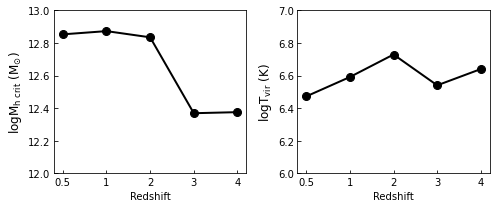

In [4]:
plt.close('all')

param_labels = {'Tvir':r'$\log \rmT_{vir}$ (K)',\
         'Mhalo':r'$\log \rmM_{h\ crit}$ $(\rmM_{\odot})$'}

inds = {'Tvir':[0,1],\
         'Mhalo':[0,0]}

ylim = {'Tvir':(6, 7),\
         'Mhalo':(12, 13)}

tick_loc = {'Tvir':[1.0, 0.5],\
         'Mhalo':[0.5, 0.1]}

size = 100
marker = 'o-'
offset = 0.075
dupoff = 0.15

redshifts = ['0.5', '1', '2', '3', '4']
    
fig = plt.figure(figsize=(7,3))
gs = gridspec.GridSpec(1, 2)

for key in param_labels.keys():
    ax = fig.add_subplot(gs[inds[key][0], inds[key][1]])
    ax.set_ylim(ylim[key])
    ax.set_ylabel(param_labels[key], fontsize=12)
    
#     ax.yaxis.set_major_locator(ticker.MultipleLocator(tick_loc[key][0]))
#     ax.yaxis.set_minor_locator(ticker.MultipleLocator(tick_loc[key][1]))
    Mscrit_fi = fixed_paramsF_a1['Mscrit']
    Mscrit_ev = varied_paramsF_a1['Mscrit']
    print(Mscrit_ev)
    Tvir_ev = []
    Mhalocrit_ev = []
    for z, Mscrit in zip(redshifts, Mscrit_ev):
        Mhalocrit, Tvir = get_Tvir(Mscrit, float(z))
        Tvir_ev.append(Tvir)
        Mhalocrit_ev.append(Mhalocrit)
    print(np.log10(Tvir_ev), np.log10(Mhalocrit_ev))
    if key == 'Tvir':
        a, = ax.plot(redshifts, np.log10(Tvir_ev), '-o', c='k', ms = 8, lw = 2)
    elif key == 'Mhalo':
        a, = ax.plot(redshifts, np.log10(Mhalocrit_ev), '-o', c='k', ms = 8, lw = 2)
    ax.tick_params(axis='both', which='both', direction='in')
    ax.set_xlabel('Redshift')

    
plt.tight_layout()
plt.subplots_adjust(hspace = .001)

plt.savefig('paper_plots/virial_temp.pdf')
